<a href="https://colab.research.google.com/github/apirakqqqqq/GE337_Programming/blob/main/Lab_4/Untitled7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install geopandas rasterio folium shapely matplotlib -q

import rasterio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


นำเข้าข้อมูล

In [3]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# 🔧 แก้ path ให้ตรงของคุณ
base = "/content/drive/MyDrive/LAB4/"

elev = rasterio.open(base + "Songkhla_Elevation.tif").read(1)
slope = rasterio.open(base + "Songkhla_Slope.tif").read(1)
rain = rasterio.open(base + "Songkhla_Rainfall.tif").read(1)
water = rasterio.open(base + "Songkhla_WaterDistance.tif").read(1)
land = rasterio.open(base + "Songkhla_LandCover.tif").read(1)

Normoalize

In [4]:
def normalize(arr):
    return (arr - np.nanmin(arr)) / (np.nanmax(arr) - np.nanmin(arr))

# Elevation (ต่ำ = เสี่ยงสูง)
elev_norm = 1 - normalize(elev)

# Slope (ต่ำ = เสี่ยงสูง)
slope_norm = 1 - normalize(slope)

# Rainfall (มาก = เสี่ยงสูง)
rain_norm = normalize(rain)

# Distance to water (ใกล้ = เสี่ยงสูง)
water_norm = 1 - normalize(water)

# Land cover (normalize)
land_norm = normalize(land)

ค่าของแต่ละปัจจัยถูกปรับให้อยู่ในช่วง 0–1 โดยใช้วิธี min-max normalization เพื่อให้สามารถนำมารวมกันในโมเดลได้ เนื่องจากแต่ละปัจจัยมีหน่วยและช่วงค่าที่แตกต่างกัน โดยกำหนดให้ค่าที่สูงแทนความเสี่ยงสูง เช่น พื้นที่ที่มีความสูงต่ำและอยู่ใกล้แหล่งน้ำถูกปรับให้มีค่าความเสี่ยงสูง

In [5]:
from rasterio.enums import Resampling

# ใช้ elevation เป็น reference
ref = rasterio.open(base + "Songkhla_Elevation.tif")

def resample_to_ref(path):
    with rasterio.open(path) as src:
        data = src.read(
            out_shape=(1, ref.height, ref.width),
            resampling=Resampling.bilinear
        )[0]
    return data

rain = resample_to_ref(base + "Songkhla_Rainfall.tif")
water = resample_to_ref(base + "Songkhla_WaterDistance.tif")
land = resample_to_ref(base + "Songkhla_LandCover.tif")

rain_norm = normalize(rain)
water_norm = 1 - normalize(water)
land_norm = normalize(land)

Align / Resample เพราะ resolution ไม่เท่ากัน ต้องทำการ combine ก่อน

In [6]:
flood = (
    (0.30 * elev_norm) +
    (0.25 * rain_norm) +
    (0.20 * water_norm) +
    (0.15 * slope_norm) +
    (0.10 * land_norm)
)

โมเดลนี้ใช้วิธี Weighted Linear Combination โดยกำหนดน้ำหนักให้แต่ละปัจจัยตามความสำคัญ โดย Elevation มีน้ำหนักสูงสุดเนื่องจากเป็นตัวกำหนดการไหลของน้ำ รองลงมาคือ Rainfall ซึ่งเป็นตัวกระตุ้นการเกิดน้ำท่วม ส่วน Distance to Water, Slope และ Land Cover มีผลรองลงมาตามลำดับ

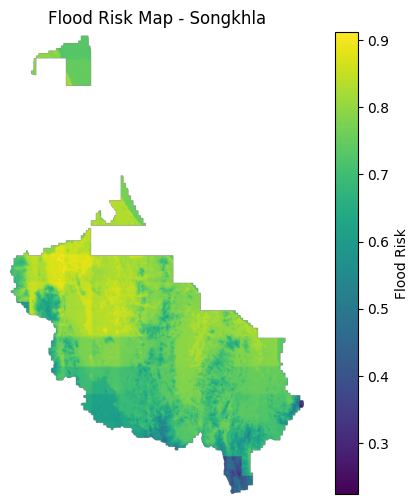

In [7]:
plt.figure(figsize=(8,6))
plt.imshow(flood)
plt.colorbar(label='Flood Risk')
plt.title('Flood Risk Map - Songkhla')
plt.axis('off')
plt.show()

พื้นที่ว่าง (NoData) ที่ปรากฏในแผนที่เกิดจากความไม่สอดคล้องของขอบเขตและความละเอียดเชิงพื้นที่ของข้อมูลแต่ละปัจจัย ทำให้บางพิกเซลไม่มีข้อมูลครบสำหรับการคำนวณ ขณะที่ผลลัพธ์โดยรวมแสดงให้เห็นว่าพื้นที่เสี่ยงน้ำท่วมสูงกระจุกตัวในบริเวณพื้นที่ราบต่ำและระบายน้ำไม่ดี ส่วนพื้นที่เสี่ยงต่ำอยู่ในบริเวณที่มีความสูงและความลาดชันมากกว่า ซึ่งสอดคล้องกับลักษณะภูมิประเทศของพื้นที่ศึกษา

ลองเปลี่ยนน้ำหนักของปัจจัยที่สำคัญที่สุด ±20%

In [8]:
# baseline
flood_base = (
    (0.30 * elev_norm) +
    (0.25 * rain_norm) +
    (0.20 * water_norm) +
    (0.15 * slope_norm) +
    (0.10 * land_norm)
)

# +20% elevation
flood_high = (
    (0.36 * elev_norm) +
    (0.23 * rain_norm) +
    (0.18 * water_norm) +
    (0.14 * slope_norm) +
    (0.09 * land_norm)
)

# -20% elevation
flood_low = (
    (0.24 * elev_norm) +
    (0.27 * rain_norm) +
    (0.22 * water_norm) +
    (0.16 * slope_norm) +
    (0.11 * land_norm)
)

diff_high = flood_high - flood_base
diff_low = flood_low - flood_base

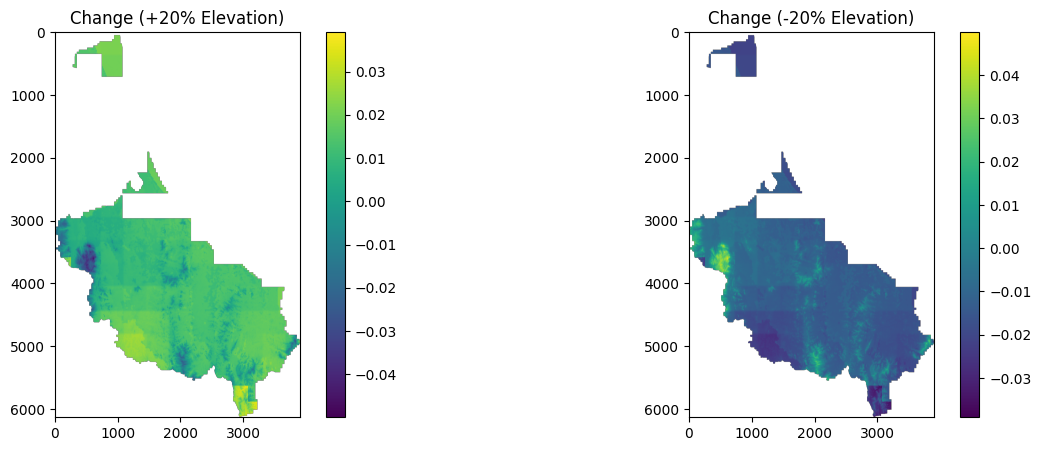

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.imshow(diff_high)
plt.title("Change (+20% Elevation)")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(diff_low)
plt.title("Change (-20% Elevation)")
plt.colorbar()

plt.show()


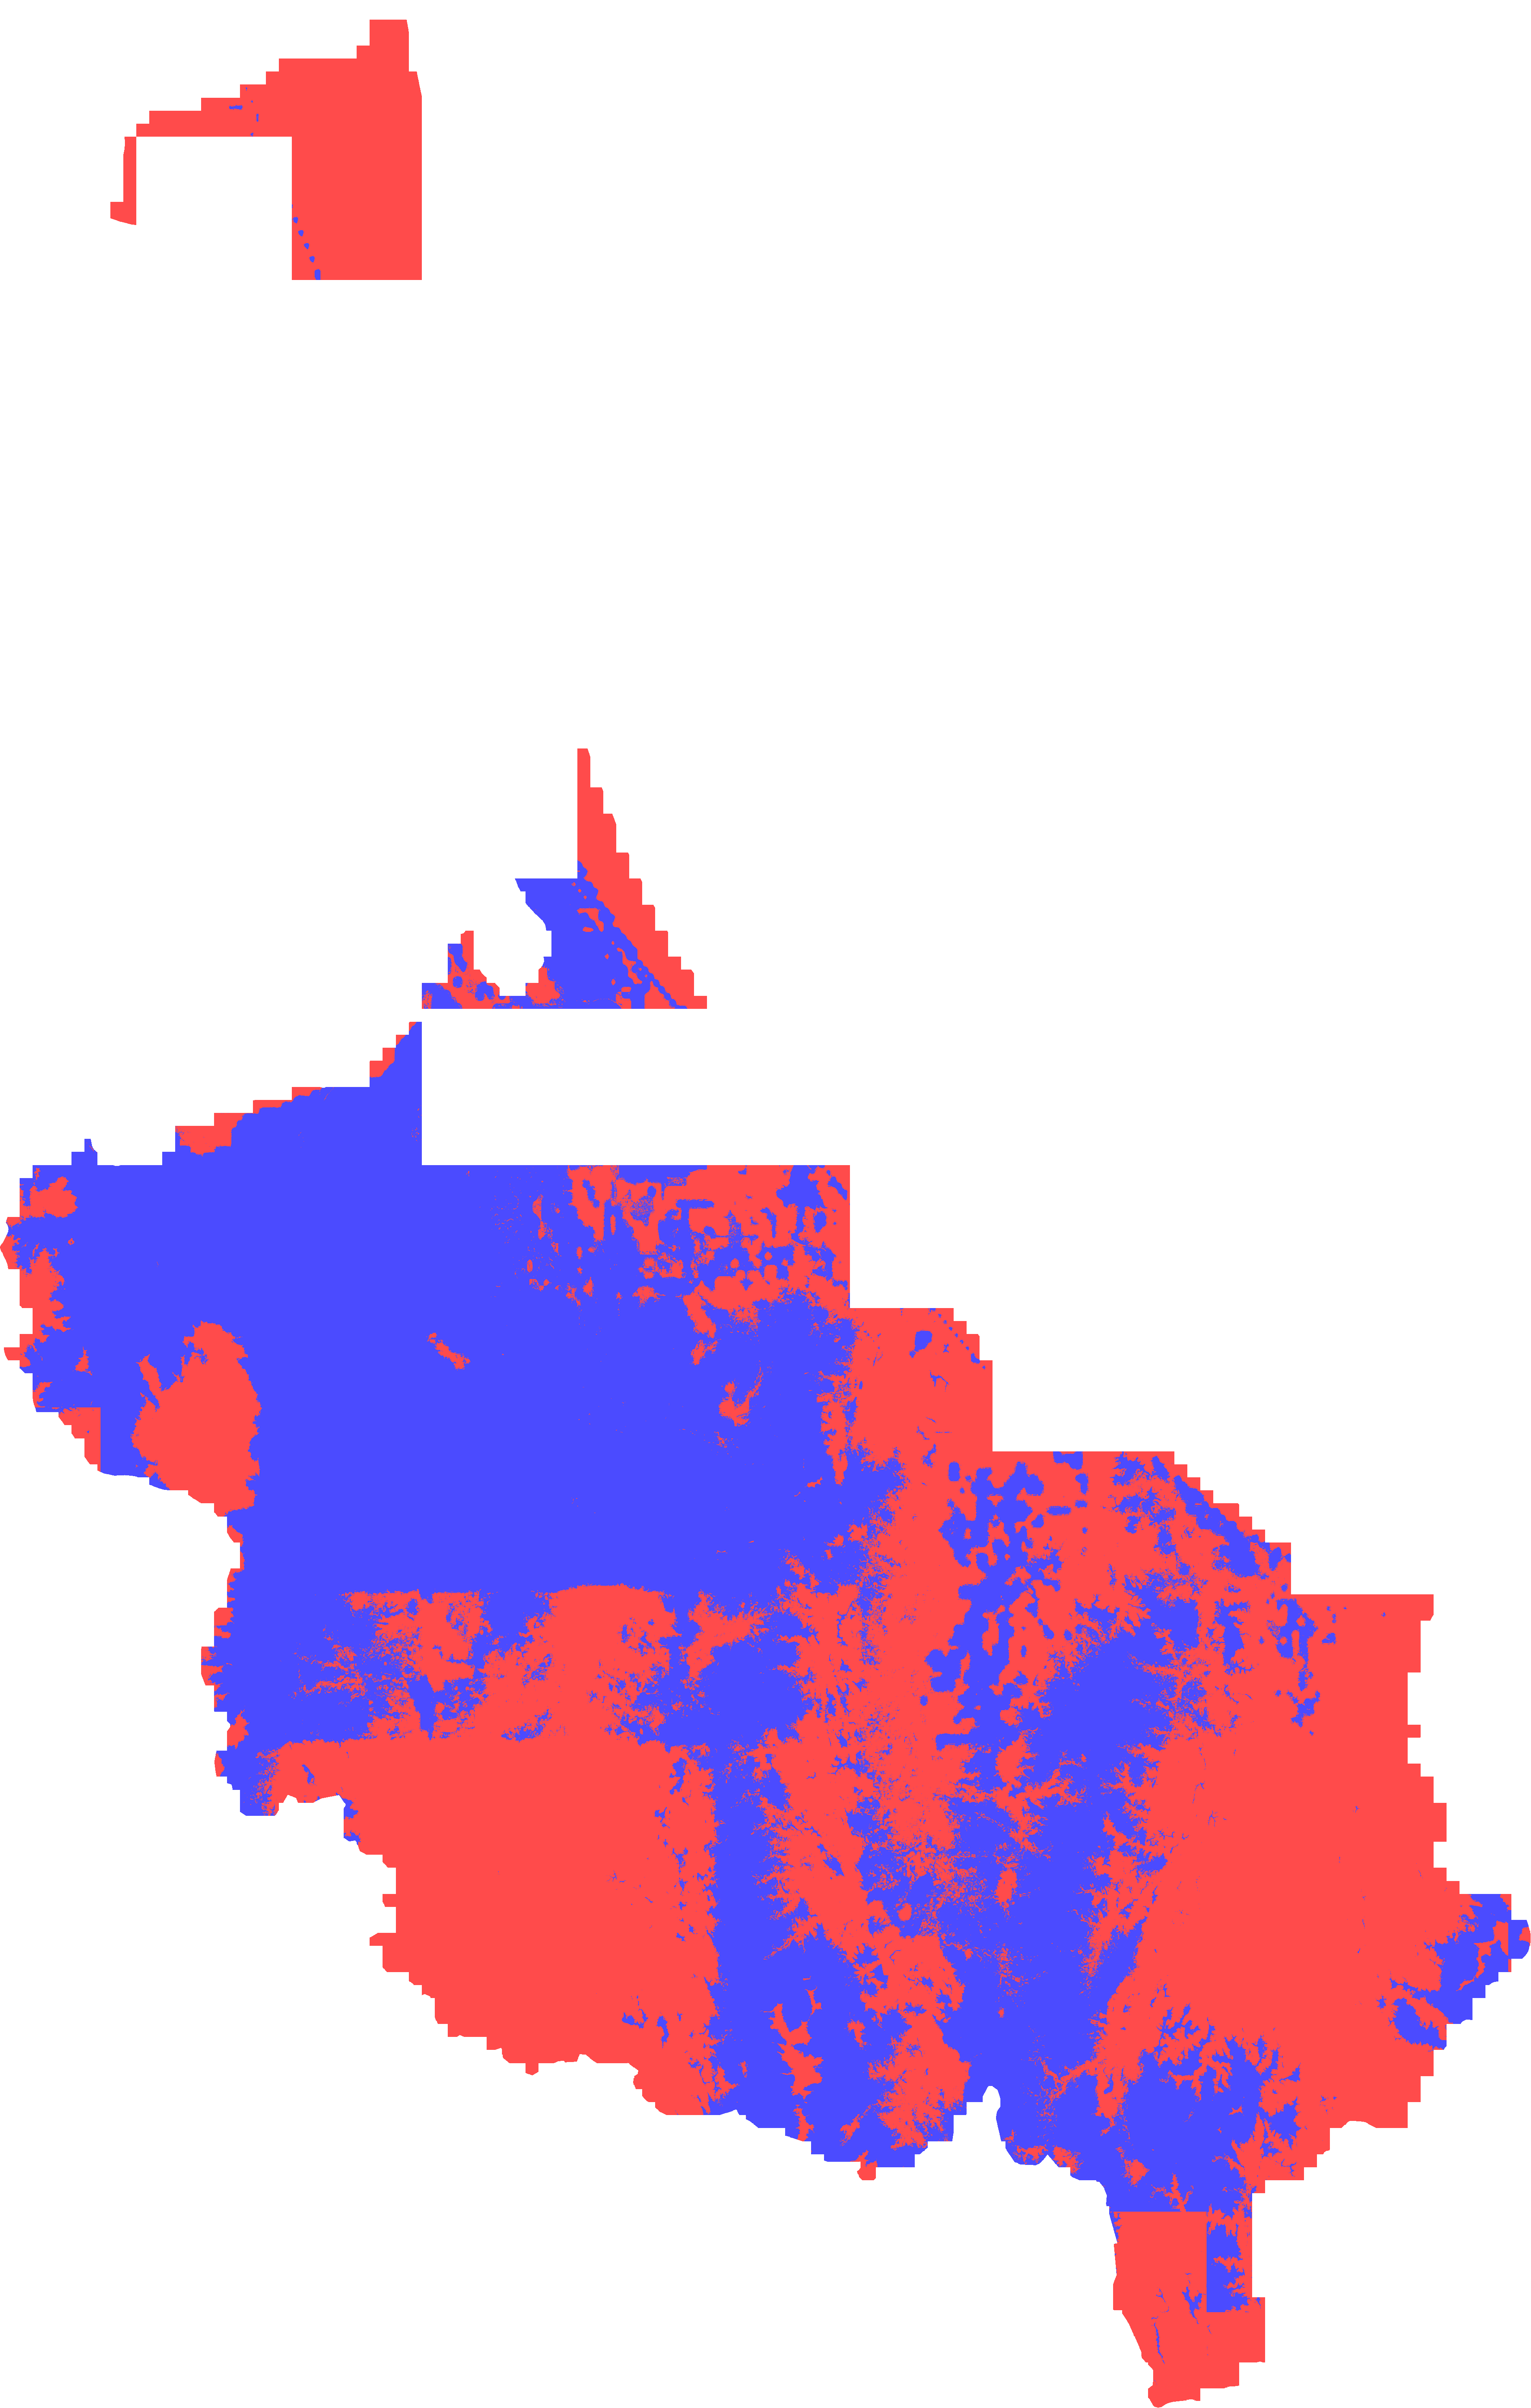

In [20]:

base_path = "/content/drive/MyDrive/LAB4/"

# =========================
# 2. Reference Raster
# =========================
with rasterio.open(base_path + "Songkhla_Elevation.tif") as ref:
    ref_data = ref.read(1)
    ref_profile = ref.profile
    bounds = ref.bounds

mask = np.isfinite(ref_data)

# =========================
# 3. Resample Function
# =========================
def load_match(path):
    with rasterio.open(path) as src:
        data = src.read(
            1,
            out_shape=(ref_profile["height"], ref_profile["width"]),
            resampling=Resampling.bilinear
        )
    return data

# =========================
# 4. Load Data
# =========================
elev = load_match(base_path + "Songkhla_Elevation.tif")
slope = load_match(base_path + "Songkhla_Slope.tif")
rain = load_match(base_path + "Songkhla_Rainfall.tif")
water = load_match(base_path + "Songkhla_WaterDistance.tif")
land = load_match(base_path + "Songkhla_LandCover.tif")

# =========================
# 5. Normalize
# =========================
def norm(x):
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x) + 1e-9)

elev_n = 1 - norm(elev)
slope_n = 1 - norm(slope)
rain_n = norm(rain)
water_n = 1 - norm(water)
land_n = norm(land)

# =========================
# 6. Model
# =========================
flood_base = (
    0.30 * elev_n +
    0.25 * rain_n +
    0.20 * water_n +
    0.15 * slope_n +
    0.10 * land_n
)

flood_high = (
    0.36 * elev_n +
    0.23 * rain_n +
    0.18 * water_n +
    0.14 * slope_n +
    0.09 * land_n
)

# =========================
# 7. Sensitivity
# =========================
diff = np.abs(flood_high - flood_base)
threshold = np.nanmean(diff)

result = np.full(diff.shape, np.nan)
result[diff < threshold] = 1   # Robust
result[diff >= threshold] = 2  # Sensitive

# ใช้ mask ตัดพื้นที่
result[~mask] = np.nan

# =========================
# 8. แปลงเป็น RGBA (แก้กรอบดำ)
# =========================
rgba = np.zeros((result.shape[0], result.shape[1], 4), dtype=np.uint8)

# Robust = น้ำเงิน
rgba[result == 1] = [0, 0, 255, 180]

# Sensitive = แดง
rgba[result == 2] = [255, 0, 0, 180]

# ❗ พื้นที่นอก = โปร่งใส
rgba[np.isnan(result)] = [0, 0, 0, 0]

# =========================
# 9. Interactive Map
# =========================
minx, miny, maxx, maxy = bounds

center_lat = (miny + maxy) / 2
center_lon = (minx + maxx) / 2

m = folium.Map(location=[center_lat, center_lon], zoom_start=9)

folium.raster_layers.ImageOverlay(
    image=rgba,
    bounds=[[miny, minx], [maxy, maxx]],
).add_to(m)

# =========================
# 10. Legend
# =========================
legend_html = '''
<div style="
position: fixed;
bottom: 50px; left: 50px; width: 180px; height: 90px;
background-color: white; z-index:9999; font-size:14px;
border:2px solid grey; padding: 10px;
">
<b>Sensitivity Map</b><br>
<span style="color:blue;">■</span> Robust (คงที่)<br>
<span style="color:red;">■</span> Sensitive (ไม่แน่นอน)
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

m.save("Sensitivity_Map.html")

m

แผนที่นี้แสดงให้เห็นว่าพื้นที่ที่มีความคงที่ของโมเดลกระจายอยู่ในบริเวณที่มีลักษณะภูมิประเทศชัดเจน ขณะที่พื้นที่ที่มีความไม่แน่นอนมักอยู่ในบริเวณรอยต่อของปัจจัย ซึ่งมีความไวต่อการเปลี่ยนแปลงของน้ำหนักในโมเดล